<a href="https://colab.research.google.com/github/sapienology/machine-learning-project/blob/main/vehicle%20using%20pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import numpy as np
import pandas as pd

In [16]:
df1 = pd.read_csv('/content/vehicle.csv')

In [17]:
df1

,COMPACTNESS,CIRCULARITY,DISTANCE CIRCULARITY,RADIUS RATIO,PR AXIS ASPECT RATIO,MAX LENGTH ASPECT RATIO,SCATTER RATIO,ELONGATEDNESS,PR AXISRECTANGULAR,LENGTHRECTANGULAR,MAJORVARIANCE,MINORVARIANCE,GYRATIONRADIUS,MAJORSKEWNESS,MINORSKEWNESS,MINORKURTOSIS,MAJORKURTOSIS,HOLLOWS RATIO,target
0,95.0,43.0,96.0,202.0,65.0,10.0,189.0,35.0,22.0,143.0,217.0,534.0,166.0,71.0,6.0,27.0,190.0,197.0,1
1,96.0,52.0,104.0,222.0,67.0,9.0,198.0,33.0,23.0,163.0,217.0,589.0,226.0,67.0,12.0,20.0,192.0,201.0,1
2,107.0,52.0,101.0,218.0,64.0,11.0,202.0,33.0,23.0,164.0,219.0,610.0,192.0,65.0,17.0,2.0,197.0,206.0,1
3,97.0,37.0,78.0,181.0,62.0,8.0,161.0,41.0,20.0,131.0,182.0,389.0,117.0,62.0,2.0,28.0,203.0,211.0,1
4,96.0,54.0,104.0,175.0,58.0,10.0,215.0,31.0,24.0,175.0,221.0,682.0,222.0,75.0,13.0,23.0,186.0,194.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
841,88.0,40.0,55.0,114.0,53.0,7.0,132.0,53.0,18.0,139.0,142.0,249.0,158.0,87.0,0.0,7.0,176.0,183.0,4
842,86.0,39.0,62.0,129.0,59.0,6.0,116.0,57.0,17.0,135.0,137.0,203.0,145.0,64.0,7.0,9.0,199.0,204.0,4
843,94.0,47.0,85.0,333.0,138.0,49.0,155.0,43.0,19.0,155.0,320.0,354.0,187.0,135.0,12.0,9.0,188.0,196.0,4
844,86.0,40.0,66.0,139.0,59.0,7.0,122.0,54.0,17.0,139.0,145.0,225.0,143.0,63.0,7.0,11.0,202.0,208.0,4


In [18]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   COMPACTNESS              846 non-null    float64
 1   CIRCULARITY              846 non-null    float64
 2   DISTANCE CIRCULARITY     846 non-null    float64
 3   RADIUS RATIO             846 non-null    float64
 4   PR AXIS ASPECT RATIO     846 non-null    float64
 5   MAX LENGTH ASPECT RATIO  846 non-null    float64
 6   SCATTER RATIO            846 non-null    float64
 7   ELONGATEDNESS            846 non-null    float64
 8   PR AXISRECTANGULAR       846 non-null    float64
 9   LENGTHRECTANGULAR        846 non-null    float64
 10  MAJORVARIANCE            846 non-null    float64
 11  MINORVARIANCE            846 non-null    float64
 12  GYRATIONRADIUS           846 non-null    float64
 13  MAJORSKEWNESS            846 non-null    float64
 14  MINORSKEWNESS            8

In [19]:
df1.shape

(846, 19)

In [20]:
df1.isnull().sum()

,0
COMPACTNESS,0
CIRCULARITY,0
DISTANCE CIRCULARITY,0
RADIUS RATIO,0
PR AXIS ASPECT RATIO,0
MAX LENGTH ASPECT RATIO,0
SCATTER RATIO,0
ELONGATEDNESS,0
PR AXISRECTANGULAR,0
LENGTHRECTANGULAR,0


In [21]:
for column in df1.columns:
    if df1[column].isnull().any():
        if df1[column].dtype != 'object': # Only fill numeric columns with mean
            mean_value = df1[column].mean()
            df1[column].fillna(mean_value, inplace=True)

In [22]:
for x in df1.columns:
  if df1[x].isnull().any():
    if x in df1[column] != 'object':
      mean = df1[column].mean()
      df1[column].fillna(mean, inplace = True)

In [23]:
df1.isnull().sum()

,0
COMPACTNESS,0
CIRCULARITY,0
DISTANCE CIRCULARITY,0
RADIUS RATIO,0
PR AXIS ASPECT RATIO,0
MAX LENGTH ASPECT RATIO,0
SCATTER RATIO,0
ELONGATEDNESS,0
PR AXISRECTANGULAR,0
LENGTHRECTANGULAR,0


In [24]:
df1['target'].unique()

array([1, 2, 3, 4])

In [25]:
df1['target'] = df1['target'].replace({
    'van' :1,
    'car' : 2,
    'bus' : 3
})

In [26]:
df1['target'].dtype

dtype('int64')

In [27]:
x = df1.drop(columns = 'target')

## Data Standardization

Many machine learning algorithms, especially those that rely on distance calculations (like K-Means clustering and PCA), are sensitive to the scale of the input features. If features have different scales, features with larger values might dominate the distance metrics, leading to biased results.

`StandardScaler` transforms the data such that its distribution has a mean of 0 and a standard deviation of 1. This process is often called Z-score normalization or standardization.

In [28]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler to the data and transform it
x_scaled = scaler.fit_transform(x)

# Convert the scaled data back to a DataFrame for easier inspection (optional)
x_scaled_df = pd.DataFrame(x_scaled, columns=x.columns)

print("Shape of scaled data:", x_scaled.shape)
display(x_scaled_df.head())

Shape of scaled data: (846, 18)


,COMPACTNESS,CIRCULARITY,DISTANCE CIRCULARITY,RADIUS RATIO,PR AXIS ASPECT RATIO,MAX LENGTH ASPECT RATIO,SCATTER RATIO,ELONGATEDNESS,PR AXISRECTANGULAR,LENGTHRECTANGULAR,MAJORVARIANCE,MINORVARIANCE,GYRATIONRADIUS,MAJORSKEWNESS,MINORSKEWNESS,MINORKURTOSIS,MAJORKURTOSIS,HOLLOWS RATIO
0,0.160580,-0.301920,0.882576,0.988243,0.419371,0.311542,0.606789,-0.760068,0.547076,-0.344578,0.904336,0.532814,-0.267570,-0.195411,-0.076711,1.613351,0.173267,0.183957
1,0.282093,1.157646,1.390119,1.586108,0.673062,0.094079,0.877667,-1.016250,0.933086,1.034060,0.904336,0.844273,1.577037,-0.729989,1.143931,0.829122,0.497926,0.721997
2,1.618730,1.157646,1.199790,1.466535,0.292525,0.529004,0.998057,-1.016250,0.933086,1.102992,0.968079,0.963194,0.531760,-0.997277,2.161133,-1.187468,1.309574,1.394546
3,0.403605,-1.274963,-0.259396,0.360485,0.038833,-0.123383,-0.235942,0.008479,-0.224944,-1.171761,-0.211156,-0.288306,-1.773999,-1.398210,-0.890472,1.725384,2.283552,2.067095
4,0.282093,1.481994,1.390119,0.181126,-0.468550,0.311542,1.389324,-1.272432,1.319096,1.861243,1.031821,1.370922,1.454064,0.339166,1.347372,1.165220,-0.476052,-0.219572


## K-Means Clustering and Elbow Method

K-Means is an unsupervised clustering algorithm that partitions data into `k` clusters. To determine the optimal number of clusters (`k`), the **Elbow Method** is commonly used. This method plots the within-cluster sum of squares (WCSS) against the number of clusters (`k`). The 'elbow' point in the plot, where the rate of decrease in WCSS significantly slows down, is typically considered the optimal `k`.

We will calculate the WCSS for a range of `k` values (e.g., from 1 to 10) and visualize the results.

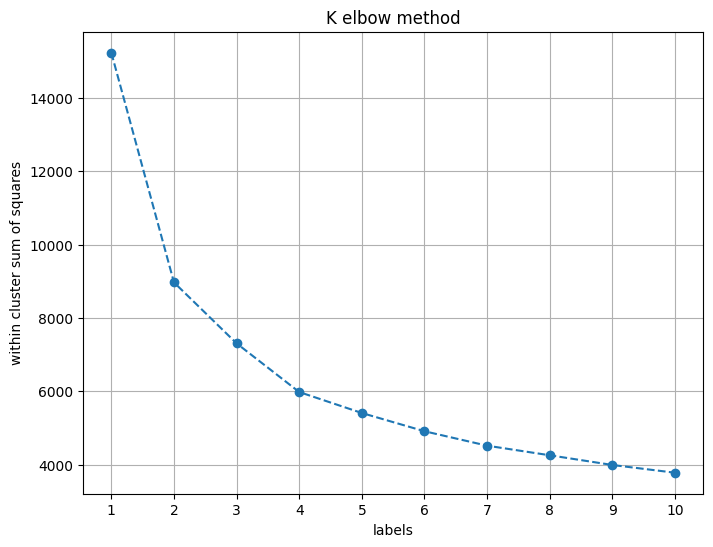

In [29]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

n_cluster = []

for y  in range(1,11) :
  kmeans = KMeans(n_clusters = y ,init = 'k-means++' , random_state = 42 , n_init = 10)
  kmeans.fit(x_scaled)
  n_cluster.append(kmeans.inertia_)

plt.figure(figsize = (8,6))
plt.plot(range(1,11) , n_cluster, marker = 'o' , linestyle = '--' )
plt.title('K elbow method')
plt.xlabel('labels')
plt.ylabel('within cluster sum of squares')
plt.xticks(range(1,11))
plt.grid(True)
plt.show()


## Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a dimensionality reduction technique. It transforms a set of possibly correlated variables into a smaller set of uncorrelated variables called principal components. These components capture the most variance in the data, allowing for easier visualization and potentially improving model performance by reducing noise.

We will apply PCA to the standardized data and then visualize the data in 2 dimensions, which can be useful for understanding underlying patterns or clusters.

Explained variance ratio by each principal component: [0.52378531 0.16793404]
Total explained variance by 2 components: 0.6917193526273826


,Principal Component 1,Principal Component 2
0,1.544291,0.806329
1,3.664223,0.922105
2,3.788722,1.937588
3,-1.062921,4.028445
4,3.989150,-1.178758


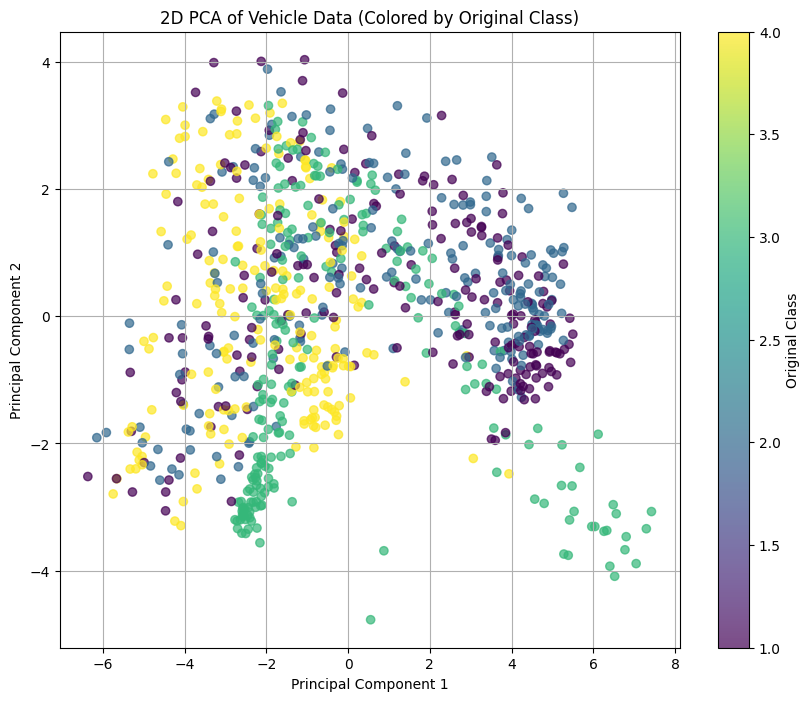

In [32]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Define x_scaled - code moved from previous cell 0d25096e
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# Initialize PCA to reduce to 2 components for visualization
pca = PCA(n_components=2)

# Fit PCA to the scaled data and transform it
x_pca = pca.fit_transform(x_scaled)

# Create a DataFrame for the PCA results
x_pca_df = pd.DataFrame(data=x_pca, columns=['Principal Component 1', 'Principal Component 2'])

print("Explained variance ratio by each principal component:", pca.explained_variance_ratio_)
print("Total explained variance by 2 components:", sum(pca.explained_variance_ratio_))

display(x_pca_df.head())

# Optional: Visualize the PCA results (colored by original 'class' if available, or by predicted cluster after K-Means)
plt.figure(figsize=(10, 8))
plt.scatter(x_pca_df['Principal Component 1'], x_pca_df['Principal Component 2'], c=df1['target'], cmap='viridis', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2D PCA of Vehicle Data (Colored by Original Class)')
plt.colorbar(label='Original Class')
plt.grid(True)
plt.show()

In [33]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 4)

x_pca = pca.fit_transform(x_scaled)

x_pca_df = pd.DataFrame(data = x_pca , columns = ['Pca 1' ,
                                                  'Pca 2','Pca 3',
                                                  'Pca 4'])

print("Explained variance ratio by each principal component:" , pca.explained_variance_ratio_)
print("Total explained variance by 2 components:", sum(pca.explained_variance_ratio_))

Explained variance ratio by each principal component: [0.52378531 0.16793404 0.10547669 0.06567714]
Total explained variance by 2 components: 0.862873179458725
